# Heart Disease Prediction with Naive Bayes

**Predicting heart disease presence using Gaussian Naive Bayes classification**

---

| Detail | Value |
|--------|-------|
| **Dataset** | UCI Heart Disease Dataset |
| **Techniques** | Gaussian Naive Bayes, RobustScaler, LabelEncoder, Confusion Matrix |
| **Author** | Ahmed Alnahrawy |



## 1. Setup & Data Loading

Import libraries and load the UCI Heart Disease dataset.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv(                   '../data/heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



## 2. Data Exploration

Inspect features, missing values, and target variable distribution.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)


## 3. Preprocessing & Feature Engineering

Encode categorical features, handle missing data, and scale numerics.


In [6]:
import numpy as np
from sklearn.impute import KNNImputer

df['chol'] = df['chol'].replace(0, np.nan)
df['trestbps'] = df['trestbps'].replace(0, np.nan)

df.drop(columns=['id', 'dataset', 'ca'], inplace=True)

df['thal'] = df['thal'].fillna('Unknown')
df['slope'] = df['slope'].fillna('Unknown')

In [7]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).drop(columns=['num']).columns
cat_cols = df.select_dtypes(include=['object', 'bool']).columns
imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isna().sum()

C:\Users\medoc\AppData\Local\Temp\ipykernel_26052\1245316090.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [8]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df.head()

,age,trestbps,chol,thalch,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,63.0,145.0,233.0,150.0,2.3,0,True,False,False,True,True,False,False,False,True,False,False,True,False,False
1,67.0,160.0,286.0,108.0,1.5,2,True,False,False,False,False,False,False,True,False,True,False,False,True,False
2,67.0,120.0,229.0,129.0,2.6,1,True,False,False,False,False,False,False,True,False,True,False,False,False,True
3,37.0,130.0,250.0,187.0,3.5,0,True,False,True,False,False,True,False,False,True,False,False,False,True,False
4,41.0,130.0,204.0,172.0,1.4,0,False,True,False,False,False,False,False,False,False,False,True,False,True,False


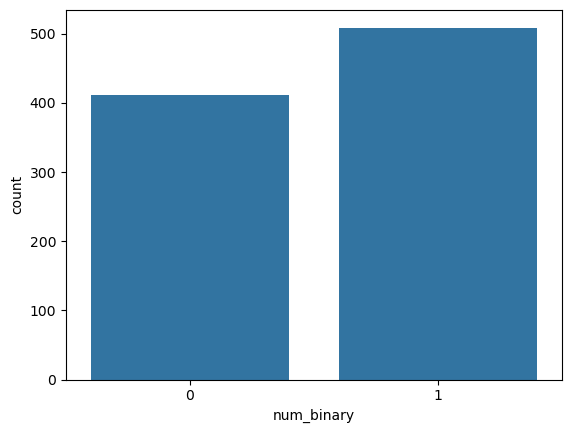

In [9]:
df['num_binary'] = (df['num'] > 0).astype(int)

sns.countplot(x=df['num_binary'])
plt.show()

In [10]:
from sklearn.preprocessing import RobustScaler

X = df.drop(columns=['num', 'num_binary'])
y_bin = df['num_binary']

X_train, X_test, y_train_bin, y_test_bin = train_test_split(X, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Naive Bayes Classification

Train Gaussian Naive Bayes model and evaluate with confusion matrix and classification report.


Accuracy: 0.8206521739130435
              precision    recall  f1-score   support

           0       0.79      0.82      0.80        82
           1       0.85      0.82      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



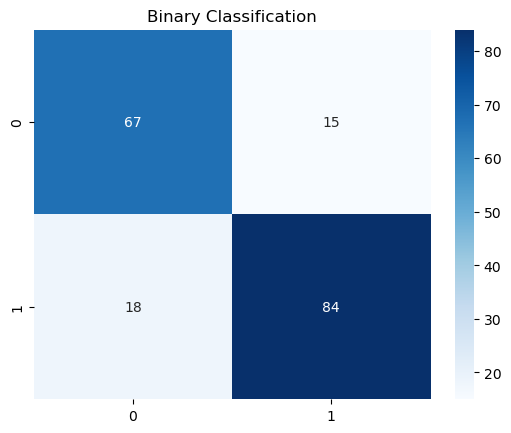

In [11]:
from sklearn.metrics import confusion_matrix

nb_bin = GaussianNB()
nb_bin.fit(X_train_scaled, y_train_bin)
y_pred_bin = nb_bin.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test_bin, y_pred_bin))
print(classification_report(y_test_bin, y_pred_bin))

cm = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Binary Classification")
plt.show()

Multi-Class Classification
0.47058823529411764
              precision    recall  f1-score   support

           1       0.57      0.72      0.63        53
           2       0.27      0.27      0.27        22
           3       0.33      0.19      0.24        21
           4       0.00      0.00      0.00         6

    accuracy                           0.47       102
   macro avg       0.29      0.30      0.29       102
weighted avg       0.42      0.47      0.44       102



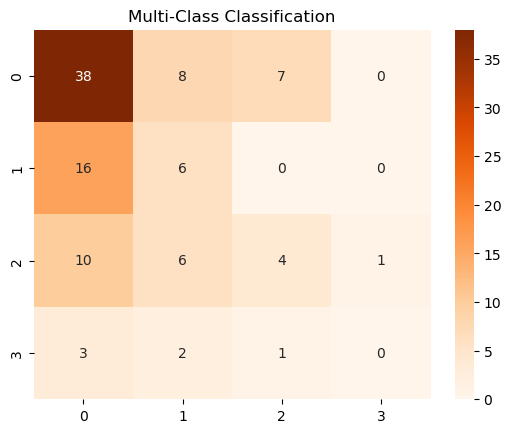

In [12]:
df_disease = df[df['num'] > 0]
X_multi = df_disease.drop(columns=['num', 'num_binary'])
y_multi = df_disease['num']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi)

scaler_m = RobustScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier

selector_m = SelectKBest(score_func=f_classif, k=10)
X_train_m_selected = selector_m.fit_transform(X_train_m_scaled, y_train_m)
X_test_m_selected = selector_m.transform(X_test_m_scaled)

knn_multi = KNeighborsClassifier(weights='distance', n_neighbors=5)
knn_multi.fit(X_train_m_selected, y_train_m)
y_pred_m = knn_multi.predict(X_test_m_selected)

print("Multi-Class Classification")
print( accuracy_score(y_test_m, y_pred_m))
print(classification_report(y_test_m, y_pred_m))

cm_m = confusion_matrix(y_test_m, y_pred_m)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Oranges')
plt.title("Multi-Class Classification")
plt.show()

0.7336956521739131
              precision    recall  f1-score   support

           0       0.79      0.82      0.80        82
           1       0.60      0.67      0.63        48
           2       0.75      0.68      0.71        31
           3       0.81      0.68      0.74        19
           4       1.00      0.50      0.67         4

    accuracy                           0.73       184
   macro avg       0.79      0.67      0.71       184
weighted avg       0.74      0.73      0.73       184



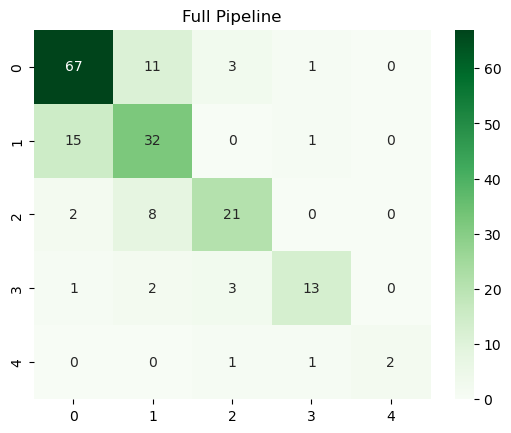

In [13]:
y_pred_final = []

for i in range(len(y_pred_bin)):
    pred_bin = y_pred_bin[i]
    if pred_bin == 0:
        y_pred_final.append(0)
    else:
        instance = X_test.iloc[[i]] 
        instance_scaled = scaler_m.transform(instance)
        instance_selected = selector_m.transform(instance_scaled)
        pred_multi = knn_multi.predict(instance_selected)[0]
        y_pred_final.append(pred_multi)

y_test_original = df.loc[X_test.index, 'num']
print( accuracy_score(y_test_original, y_pred_final))
print(classification_report(y_test_original, y_pred_final))

cm_final = confusion_matrix(y_test_original, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens')
plt.title("Full Pipeline")
plt.show()

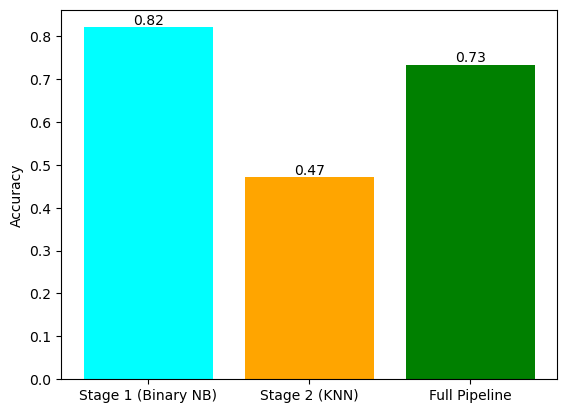

In [14]:
acc_stage1 = accuracy_score(y_test_bin, y_pred_bin)
acc_stage2 = accuracy_score(y_test_m, y_pred_m)
acc_final = accuracy_score(y_test_original, y_pred_final)

models = ['Stage 1 (Binary NB)', 'Stage 2 (KNN)', 'Full Pipeline']
accuracies = [acc_stage1, acc_stage2, acc_final]
bars = plt.bar(models, accuracies, color=['cyan', 'orange', 'green'])
plt.bar_label(bars, fmt='%.2f')
plt.ylabel('Accuracy')
plt.show()


---

## Summary

This notebook demonstrated gaussian naive bayes, robustscaler, labelencoder, confusion matrix techniques applied to the UCI Heart Disease Dataset.

**Author:** Ahmed Alnahrawy | [GitHub](https://github.com/Ahmed-Na7rawy)
